[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/<GITHUB_USER>/<REPO>/blob/main/vit5_p4_pannuke_hf_classification.ipynb)

# C-LiTE Cell Classification

Linear-probe evaluation of C-LiTE with the data pulled straight from the **Hugging Face Hub** (`RationAI/PanNuke`).

* **Data** : the three PanNuke folds are downloaded with `datasets`, and one **64×64 crop centred on each nucleus's mask centroid** is written to disk as `<CELL_CROP_ROOT>/Fold{1,2,3}_cell_patches/<Class>/*.png`, plus a per-fold `manifest.csv`. This runs once; later runs reuse the crops.
* **Model** : the C-LiTE inference architecture is defined inline
* **Features:** final-norm CLS token or mean patch token.
* **Splits:** Fold1 = train, Fold2 = val, Fold3 = test.
* **Classifiers:** logistic regression (`C = 1/l2`, `l2 = 100/(M·C)`, lbfgs) and cosine kNN.
* **Visualizations:** CLS attention maps per head and per block and PCA of patch tokens, per image and joint.

Requirements: `torch`, `torchvision`, `datasets`, `numpy`, `pillow`, `scikit-learn`, `matplotlib`, `tqdm`. No `timm`, `einops`, `flash-attn` or `xformers` needed (attention runs through `F.scaled_dot_product_attention`).

## 0. Environment setup (Colab or local)

On **Google Colab**, switch to a GPU runtime first (*Runtime → Change runtime type → T4 GPU*). This cell then:

* installs the one package Colab may be missing (`datasets`);
* mounts Google Drive, so the checkpoint can be read from it and results can be saved to it.

Put checkpoint in Drive at `MyDrive/C-LITE/teacher_checkpoint.pth`, or change `CHECKPOINT`.

In [1]:
import sys, os, subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "datasets"], check=True)
    from google.colab import drive
    drive.mount("/content/drive")
    print("Colab runtime | CPUs:", os.cpu_count())
else:
    print("Local runtime")

Mounted at /content/drive
Colab runtime | CPUs: 2


## 1. Configuration — edit these

In [3]:
from pathlib import Path


CHECKPOINT = Path("/content/c-lite.pth")
if IN_COLAB:
    CHECKPOINT = Path("/content/c-lite.pth")
MODEL_TAG = "vit5_small_p4"          # used in output file names
EXPECTED_PATCH_SIZE = 4              # sanity check against the checkpoint (None to skip)

ROPE_PT_SEQ_LEN = 224 // 16
REG_THETA = 100                      # only used if the checkpoint lacks rope_reg.freqs

HF_DATASET_ID = "RationAI/PanNuke"   # splits fold1/fold2/fold3; image, instances, categories, tissue
HF_CACHE_DIR  = None                 # e.g. "/tia/phd-data/.../hf_cache"; None = ~/.cache/huggingface

# ---- cell-centric crops ----------------------------------------------------------
CELL_CROP_ROOT   = Path("./pannuke_hf_cell_crops")
if IN_COLAB:
    CELL_CROP_ROOT = Path("/content/pannuke_hf_cell_crops")
CROP_SIZE        = 64
CROP_PAD_MODE    = "reflect"
CROP_PAD_VALUE   = 255
MIN_NUCLEUS_AREA = 10
CROP_NUM_WORKERS = min(8, os.cpu_count() or 1)
OVERWRITE_CROPS  = False

TRAIN_FOLDS = ["Fold1"]
VAL_FOLDS   = ["Fold2"]
TEST_FOLDS  = ["Fold3"]

# ---- evaluation ------------------------------------------------------------------
OUTPUT_DIR     = Path(f"./{MODEL_TAG}_pannuke_results")
if IN_COLAB:
    OUTPUT_DIR = Path(f"/content/drive/MyDrive/C-LITE/{MODEL_TAG}_pannuke_results")   # survives the session
CACHE_FEATURES = True

IMG_SIZE     = 64
FEATURE_MODE = "cls"
NORM_MEAN    = (0.485, 0.456, 0.406)
NORM_STD     = (0.229, 0.224, 0.225)
BATCH_SIZE   = 256
NUM_WORKERS  = min(4, os.cpu_count() or 1)
USE_AMP      = True
AMP_DTYPE    = "float16"             # or "bfloat16"
SEED         = 42

LOGREG_MAX_ITER = 1000
KNN_K           = 20

if IN_COLAB and not CHECKPOINT.exists():
    from google.colab import files
    print(f"{CHECKPOINT} not found -- choose the checkpoint file to upload")
    uploaded = files.upload()
    CHECKPOINT = Path("/content") / next(iter(uploaded))
assert CHECKPOINT.exists(), f"checkpoint not found: {CHECKPOINT}"
print("checkpoint:", CHECKPOINT)

checkpoint: /content/c-lite.pth


## 2. Imports & setup

In [4]:
import csv
import math
import multiprocessing as mp
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, cohen_kappa_score, log_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device,
      f"({torch.cuda.get_device_name(0)})" if device.type == "cuda" else "")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CELL_CROP_ROOT.mkdir(parents=True, exist_ok=True)

torch 2.11.0+cu128 | device: cuda (Tesla T4)


## 3. PanNuke from Hugging Face → cell-centric 64×64 crops



In [5]:
CLASSES = ["Connective", "Dead", "Epithelial", "Inflammatory", "Neoplastic"]   # our label order
IMG_EXTENSIONS = (".png", ".jpg", ".jpeg", ".tif", ".tiff")

hf_folds = {}
for fold in TRAIN_FOLDS + VAL_FOLDS + TEST_FOLDS:
    hf_folds[fold] = load_dataset(HF_DATASET_ID, split=fold.lower(), cache_dir=HF_CACHE_DIR)
    print(f"{fold}: {len(hf_folds[fold])} tiles")

_any = next(iter(hf_folds.values()))
HF_CLASS_NAMES  = _any.features["categories"].feature.names     # read from the dataset, not hard-coded
HF_TISSUE_NAMES = _any.features["tissue"].names
assert sorted(HF_CLASS_NAMES) == sorted(CLASSES), HF_CLASS_NAMES
print("HF class ids:", dict(enumerate(HF_CLASS_NAMES)))


def _safe(name):
    """Tissue names like 'Head & Neck' -> 'Head-Neck' so '_'-splitting of file names still works."""
    return name.replace(" & ", "-").replace("&", "-").replace(" ", "-").replace("_", "-")


def nucleus_centroid(mask):
    ys, xs = np.nonzero(mask)
    if ys.size == 0:
        return None
    return float(ys.mean()), float(xs.mean()), int(ys.size)


def pad_tile(img, pad):
    if CROP_PAD_MODE == "reflect":
        return np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")
    return np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode="constant", constant_values=CROP_PAD_VALUE)


def crop_centered(padded, cy, cx, size, pad):
    """Cut a size x size window whose pixel (size//2, size//2) is the centroid (cy, cx)."""
    y0 = int(round(cy)) - size // 2 + pad
    x0 = int(round(cx)) - size // 2 + pad
    return padded[y0:y0 + size, x0:x0 + size]


_CROP_JOB = {}   # set before forking so worker processes inherit the (memory-mapped) HF dataset


def _crop_tile(tile_idx):
    fold, ds = _CROP_JOB["fold"], _CROP_JOB["ds"]
    row = ds[tile_idx]
    img = np.asarray(row["image"].convert("RGB"))
    H, W = img.shape[:2]
    pad = CROP_SIZE // 2
    padded = pad_tile(img, pad)
    tissue = _safe(HF_TISSUE_NAMES[row["tissue"]])
    out_rows = []
    for nuc_idx, (inst, cat) in enumerate(zip(row["instances"], row["categories"])):
        mask = np.asarray(inst, dtype=bool)
        c = nucleus_centroid(mask)
        if c is None or c[2] < MIN_NUCLEUS_AREA:
            continue
        cy, cx, area = c
        cls = HF_CLASS_NAMES[cat]
        name = f"{fold.lower()}_{tile_idx:05d}_{nuc_idx:05d}_{cls}_{tissue}.png"
        path = CELL_CROP_ROOT / f"{fold}_cell_patches" / cls / name
        if OVERWRITE_CROPS or not path.exists():
            Image.fromarray(np.ascontiguousarray(crop_centered(padded, cy, cx, CROP_SIZE, pad))).save(path)
        touches = bool(mask[0].any() or mask[-1].any() or mask[:, 0].any() or mask[:, -1].any())
        near_edge = min(cy, cx, H - 1 - cy, W - 1 - cx) < CROP_SIZE / 2   # crop needed padding
        out_rows.append([fold, tile_idx, nuc_idx, cls, tissue, f"{cy:.2f}", f"{cx:.2f}",
                         area, int(touches), int(near_edge), str(path)])
    return out_rows


MANIFEST_HEADER = ["fold", "tile_idx", "nucleus_idx", "class", "tissue", "cy", "cx",
                   "area_px", "touches_tile_border", "padded", "path"]


def make_cell_crops(fold):
    manifest = CELL_CROP_ROOT / f"{fold}_manifest.csv"
    if manifest.exists() and not OVERWRITE_CROPS:
        print(f"{fold}: crops already exist ({manifest}), skipping. Set OVERWRITE_CROPS=True to redo.")
        return manifest
    for cls in CLASSES:
        (CELL_CROP_ROOT / f"{fold}_cell_patches" / cls).mkdir(parents=True, exist_ok=True)
    _CROP_JOB.update(fold=fold, ds=hf_folds[fold])
    idxs = range(len(hf_folds[fold]))
    rows = []
    use_pool = CROP_NUM_WORKERS > 0 and "fork" in mp.get_all_start_methods()
    if use_pool:
        with mp.get_context("fork").Pool(CROP_NUM_WORKERS) as pool:
            for r in tqdm(pool.imap(_crop_tile, idxs, chunksize=8), total=len(idxs), desc=f"Cropping {fold}"):
                rows.extend(r)
    else:
        for i in tqdm(idxs, desc=f"Cropping {fold}"):
            rows.extend(_crop_tile(i))
    tmp = manifest.with_suffix(".tmp")
    with open(tmp, "w", newline="") as f:
        w = csv.writer(f); w.writerow(MANIFEST_HEADER); w.writerows(rows)
    tmp.rename(manifest)   # manifest only appears once the whole fold finished
    counts = {c: sum(r[3] == c for r in rows) for c in CLASSES}
    print(f"{fold}: {len(rows)} nuclei -> {counts}")
    return manifest


t0 = time.time()
for fold in hf_folds:
    make_cell_crops(fold)
print(f"crop creation done in {time.time() - t0:.0f}s")

README.md:   0%|          | 0.00/4.53k [00:00<?, ?B/s]

data/fold1-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  280MB            

data/fold1-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/fold2-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  264MB            

data/fold2-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Fold1: 62411 nuclei -> {'Connective': 16158, 'Dead': 944, 'Epithelial': 8744, 'Inflammatory': 10678, 'Neoplastic': 25887}


Cropping Fold2:   0%|          | 0/2523 [00:00<?, ?it/s]

Fold2: 59083 nuclei -> {'Connective': 16527, 'Dead': 863, 'Epithelial': 8762, 'Inflammatory': 10488, 'Neoplastic': 22443}


Cropping Fold3:   0%|          | 0/2722 [00:00<?, ?it/s]

Fold3: 65764 nuclei -> {'Connective': 17207, 'Dead': 1036, 'Epithelial': 8724, 'Inflammatory': 10679, 'Neoplastic': 28118}
crop creation done in 345s


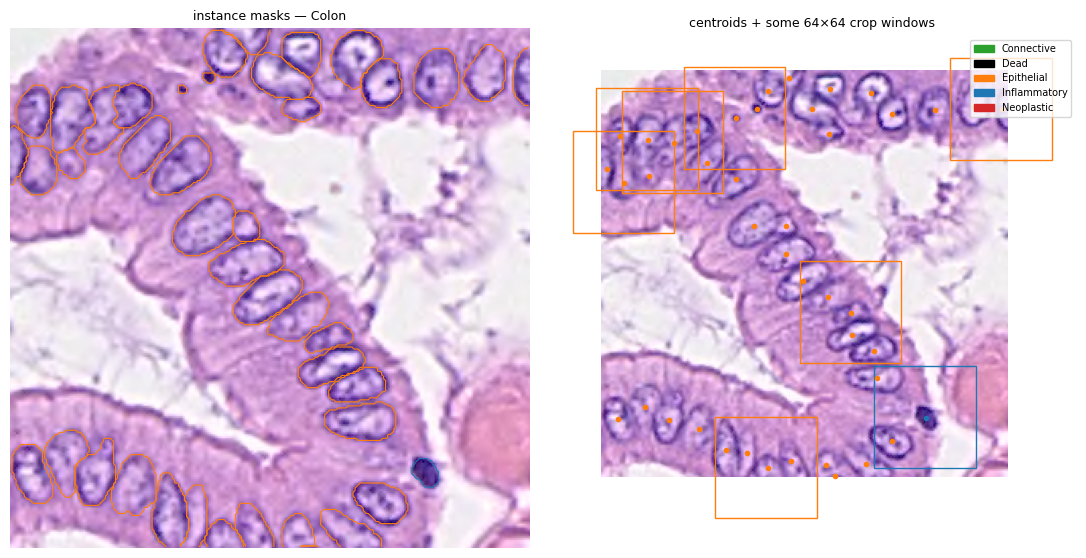

In [6]:

CLASS_COLORS = dict(zip(CLASSES, ["tab:green", "black", "tab:orange", "tab:blue", "tab:red"]))
ds0 = hf_folds[TRAIN_FOLDS[0]]
row = ds0[random.Random(SEED).randrange(len(ds0))]
img = np.asarray(row["image"].convert("RGB"))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(img); axes[1].imshow(img)
for j, (inst, cat) in enumerate(zip(row["instances"], row["categories"])):
    c = nucleus_centroid(np.asarray(inst, dtype=bool))
    if c is None:
        continue
    cls = HF_CLASS_NAMES[cat]
    axes[0].contour(np.asarray(inst, dtype=float), levels=[0.5], colors=[CLASS_COLORS[cls]], linewidths=0.8)
    axes[1].plot(c[1], c[0], "o", ms=3, color=CLASS_COLORS[cls])
    if j % 6 == 0:
        axes[1].add_patch(mpatches.Rectangle((round(c[1]) - CROP_SIZE // 2 - 0.5, round(c[0]) - CROP_SIZE // 2 - 0.5),
                                             CROP_SIZE, CROP_SIZE, fill=False, ec=CLASS_COLORS[cls], lw=1))
axes[0].set_title(f"Instance Masks — {HF_TISSUE_NAMES[row['tissue']]}", fontsize=9)
axes[1].set_title(f"Centroids {CROP_SIZE}×{CROP_SIZE} crops", fontsize=9)
for ax in axes: ax.axis("off")
axes[1].legend(handles=[mpatches.Patch(color=v, label=k) for k, v in CLASS_COLORS.items()],
               fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

## 4. C-LiTE Inference



In [7]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.variance_epsilon = eps

    def forward(self, x):
        dt = x.dtype
        x = x.float()
        x = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.variance_epsilon)
        return self.weight * x.to(dt)


def rotate_half(x):
    """(x0, x1, x2, x3, ...) -> (-x1, x0, -x3, x2, ...), same as einops version in vit5_arch."""
    x1, x2 = x.unflatten(-1, (-1, 2)).unbind(-1)
    return torch.stack((-x2, x1), dim=-1).flatten(-2)


def rope_freqs(dim, theta):
    return 1.0 / (theta ** (torch.arange(0, dim, 2)[: dim // 2].float() / dim))


class VisionRotaryEmbedding(nn.Module):
    def __init__(self, dim, pt_seq_len, theta=10000):
        super().__init__()
        self.pt_seq_len = pt_seq_len
        self.register_buffer("freqs", rope_freqs(dim, theta))
        self._cache = {}

    def _cos_sin(self, n, device, dtype):
        key = (n, device, dtype)
        if key not in self._cache:
            t = torch.arange(n, device=device) / n * self.pt_seq_len
            f = torch.outer(t, self.freqs.to(device)).repeat_interleave(2, dim=-1)    # (n, d)
            f = torch.cat([f[:, None, :].expand(n, n, -1), f[None, :, :].expand(n, n, -1)], dim=-1)
            f = f.reshape(n * n, 1, -1)                                               # (n*n, 1, head_dim)
            self._cache[key] = (f.cos().to(dtype), f.sin().to(dtype))
        return self._cache[key]

    def forward(self, x):                        # x: (B, n*n, heads, head_dim)
        n = int(math.isqrt(x.shape[1]))
        cos, sin = self._cos_sin(n, x.device, x.dtype)
        return x * cos + rotate_half(x) * sin


class Attention(nn.Module):
    def __init__(self, dim, num_heads, qkv_bias, rope_pt_seq_len, rope_reg_size, num_registers,
                 reg_theta, use_rope=True, gating_type=None):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.num_registers = num_registers
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.q_norm = RMSNorm(head_dim)
        self.k_norm = RMSNorm(head_dim)
        self.rope = VisionRotaryEmbedding(head_dim // 2, rope_pt_seq_len) if use_rope else None
        self.rope_reg = (VisionRotaryEmbedding(head_dim // 2, rope_reg_size, theta=reg_theta)
                         if rope_reg_size > 0 else None)
        self.gating_type = gating_type
        if gating_type is not None:
            self.gate_proj = nn.Linear(dim, num_heads if gating_type == "headwise" else dim)
        self.store_attn, self.last_attn = False, None

    def forward(self, x):
        x_in = x
        B, N, C = x.shape
        r = N - self.num_registers
        q, k, v = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).unbind(dim=2)
        dt = q.dtype
        q, k = self.q_norm(q).to(dt), self.k_norm(k).to(dt)
        if self.rope is not None:
            q = torch.cat((q[:, :1], self.rope(q[:, 1:r]), q[:, r:]), dim=1)
            k = torch.cat((k[:, :1], self.rope(k[:, 1:r]), k[:, r:]), dim=1)
        if self.rope_reg is not None:
            q = torch.cat((q[:, :r], self.rope_reg(q[:, r:])), dim=1)
            k = torch.cat((k[:, :r], self.rope_reg(k[:, r:])), dim=1)
        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)       # (B, heads, N, hd)
        if self.store_attn:
            attn = ((q.float() @ k.float().transpose(-2, -1)) * self.scale).softmax(-1)
            self.last_attn = attn.detach()
            x = (attn.to(v.dtype) @ v)
        else:
            x = F.scaled_dot_product_attention(q, k, v, scale=self.scale)
        x = x.transpose(1, 2).reshape(B, N, C)
        if self.gating_type is not None:                                           # Gated Attention
            g = torch.sigmoid(self.gate_proj(x_in))
            if self.gating_type == "headwise":
                g = g.unsqueeze(-1).expand(B, N, self.num_heads, C // self.num_heads).reshape(B, N, C)
            x = x * g
        return self.proj(x)


class Mlp(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()
        self.fc1, self.act, self.fc2 = nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


class Block(nn.Module):
    def __init__(self, dim, mlp_hidden, **attn_kw):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.attn = Attention(dim, **attn_kw)
        self.norm2 = RMSNorm(dim)
        self.mlp = Mlp(dim, mlp_hidden)
        self.gamma_1 = nn.Parameter(1e-4 * torch.ones(dim))
        self.gamma_2 = nn.Parameter(1e-4 * torch.ones(dim))

    def forward(self, x):
        x = x + self.gamma_1 * self.attn(self.norm1(x))
        return x + self.gamma_2 * self.mlp(self.norm2(x))


class PatchEmbed(nn.Module):
    def __init__(self, patch_size, embed_dim, in_chans=3):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class ViT5(nn.Module):
    """Inference-only C-LiTE. forward() -> final-norm CLS token."""

    def __init__(self, patch_size, embed_dim, depth, num_heads, pos_grid, num_registers, mlp_hidden,
                 qkv_bias=False, rope_pt_seq_len=14, use_rope=True, reg_theta=100, gating_type=None):
        super().__init__()
        self.patch_size, self.embed_dim, self.num_registers = patch_size, embed_dim, num_registers
        self.patch_embed = PatchEmbed(patch_size, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.reg_token = nn.Parameter(torch.zeros(1, num_registers, embed_dim)) if num_registers else None
        self.pos_embed = nn.Parameter(torch.zeros(1, pos_grid * pos_grid, embed_dim))
        self.mask_token = nn.Parameter(torch.zeros(1, embed_dim))    # unused at inference, kept for loading
        rope_reg_size = int(math.isqrt(num_registers))
        assert rope_reg_size ** 2 == num_registers, "num_registers must be a square number"
        self.blocks = nn.ModuleList([
            Block(embed_dim, mlp_hidden, num_heads=num_heads, qkv_bias=qkv_bias,
                  rope_pt_seq_len=rope_pt_seq_len, rope_reg_size=rope_reg_size, num_registers=num_registers,
                  reg_theta=reg_theta, use_rope=use_rope, gating_type=gating_type)
            for _ in range(depth)])
        self.norm = RMSNorm(embed_dim)

    def interpolate_pos_encoding(self, n_patch, h, w):

        N, dim = self.pos_embed.shape[1:]
        if n_patch == N and w == h:
            return self.pos_embed
        g = int(math.isqrt(N))
        pe = self.pos_embed.reshape(1, g, g, dim).permute(0, 3, 1, 2)
        pe = F.interpolate(pe.float(), size=(h // self.patch_size, w // self.patch_size),
                           mode="bicubic", align_corners=False).to(self.pos_embed.dtype)
        return pe.permute(0, 2, 3, 1).reshape(1, -1, dim)

    def forward_features(self, x):
        B, _, H, W = x.shape
        x = self.patch_embed(x)
        x = x + self.interpolate_pos_encoding(x.shape[1], H, W)
        x = torch.cat((self.cls_token.expand(B, -1, -1), x), dim=1)
        if self.reg_token is not None:
            x = torch.cat((x, self.reg_token.expand(B, -1, -1)), dim=1)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        R = self.num_registers
        return {"cls": x[:, 0], "patch": x[:, 1:x.shape[1] - R], "reg": x[:, x.shape[1] - R:]}

    def forward(self, x):
        return self.forward_features(x)["cls"]

In [10]:
def _normalize_state_dict(sd):
    for key in ("model", "state_dict"):
        if isinstance(sd, dict) and isinstance(sd.get(key), dict):
            sd = sd[key]
    if isinstance(sd.get("teacher"), dict):
        sd = sd["teacher"]
    elif isinstance(sd.get("student"), dict):
        print("no 'teacher' key -- using 'student' sub-dict (KD training checkpoint)")
        sd = sd["student"]
    for pref in ("teacher.backbone.", "student.backbone.", "backbone.", "module."):
        hits = {k[len(pref):].replace("_fsdp_wrapped_module.", ""): v for k, v in sd.items() if k.startswith(pref)}
        if hits:
            print(f"stripped prefix '{pref}' -> {len(hits)} tensors")
            sd = hits
            break
    heads = ("dino_head", "ibot_head", "gram_teacher", "contrastive_head", "head.")
    return {k: v for k, v in sd.items() if not k.startswith(heads)}


def build_vit5_from_state_dict(sd):
    embed_dim = sd["cls_token"].shape[-1]
    depth = 1 + max(int(k.split(".")[1]) for k in sd if k.startswith("blocks."))
    head_dim = sd["blocks.0.attn.q_norm.weight"].shape[0]
    gate_key = "blocks.0.attn.gate_proj.weight"
    num_heads = embed_dim // head_dim
    cfg = dict(
        patch_size=sd["patch_embed.proj.weight"].shape[-1],
        embed_dim=embed_dim, depth=depth, num_heads=num_heads,
        pos_grid=int(math.isqrt(sd["pos_embed"].shape[1])),
        num_registers=sd["reg_token"].shape[1] if "reg_token" in sd else 0,
        mlp_hidden=sd["blocks.0.mlp.fc1.weight"].shape[0],
        qkv_bias="blocks.0.attn.qkv.bias" in sd,
        rope_pt_seq_len=ROPE_PT_SEQ_LEN, use_rope=True, reg_theta=REG_THETA,
        gating_type=None if gate_key not in sd else ("headwise" if sd[gate_key].shape[0] == num_heads else "elementwise"),
    )
    assert cfg["pos_grid"] ** 2 == sd["pos_embed"].shape[1], "pos_embed grid must be square"
    return ViT5(**cfg), cfg


ckpt = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
state_dict = _normalize_state_dict(ckpt)
del ckpt

model, arch = build_vit5_from_state_dict(state_dict)
print("architecture:", arch)
if EXPECTED_PATCH_SIZE is not None:
    assert arch["patch_size"] == EXPECTED_PATCH_SIZE, f"checkpoint patch size is {arch['patch_size']}"

missing, unexpected = model.load_state_dict(state_dict, strict=False)
missing_ok = [k for k in missing if k.endswith(("attn.rope.freqs", "attn.rope_reg.freqs"))]
missing = [k for k in missing if k not in missing_ok]
print(f"Missing keys ({len(missing)}): {missing}" + (f"  (+{len(missing_ok)} RoPE freqs recomputed)" if missing_ok else ""))
print(f"Unexpected keys ({len(unexpected)}): {unexpected}")
assert not missing and not unexpected, "Checkpoint does not match the ViT-5 architecture"

model = model.to(device).eval()
g_in = IMG_SIZE // arch["patch_size"]
print(f"Backbone params: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M | "
      f"input {IMG_SIZE}px -> {g_in}x{g_in} patch tokens (+1 CLS, +{arch['num_registers']} reg); "
      f"pos_embed {arch['pos_grid']}x{arch['pos_grid']} -> {g_in}x{g_in}")

stripped prefix 'backbone.' -> 187 tensors
architecture: {'patch_size': 4, 'embed_dim': 384, 'depth': 12, 'num_heads': 6, 'pos_grid': 56, 'num_registers': 4, 'mlp_hidden': 1536, 'qkv_bias': False, 'rope_pt_seq_len': 14, 'use_rope': True, 'reg_theta': 100, 'gating_type': None}
Missing keys (0): []
Unexpected keys (0): []
Backbone params: 22.5M | input 64px -> 16x16 patch tokens (+1 CLS, +4 reg); pos_embed 56x56 -> 16x16


## 5. PanNuke cell-crop dataset

In [13]:
class PanNukeCellDataset(Dataset):
    def __init__(self, root, folds, transform=None):
        self.transform = transform
        self.classes = CLASSES
        self.class_to_idx = {c: i for i, c in enumerate(CLASSES)}
        self.samples = []
        for fold in folds:
            for cls in CLASSES:
                d = Path(root) / f"{fold}_cell_patches" / cls
                if not d.is_dir():
                    print(f"Warning: {d} does not exist, skipping.")
                    continue
                for p in sorted(d.iterdir()):
                    if p.suffix.lower() in IMG_EXTENSIONS:
                        self.samples.append((fold, cls, p, self.class_to_idx[cls]))
        if not self.samples:
            raise RuntimeError(f"No images found for folds {folds} under {root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fold, cls, path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path.stem

    def class_counts(self):
        counts = np.bincount([s[3] for s in self.samples], minlength=len(CLASSES))
        return dict(zip(CLASSES, counts.tolist()))


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),       # no-op for 64x64 crops
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

datasets = {
    "train": PanNukeCellDataset(CELL_CROP_ROOT, TRAIN_FOLDS, transform),
    "val":   PanNukeCellDataset(CELL_CROP_ROOT, VAL_FOLDS,   transform),
    "test":  PanNukeCellDataset(CELL_CROP_ROOT, TEST_FOLDS,  transform),
}
for split, ds in datasets.items():
    print(f"{split:5s} n={len(ds):6d}  {ds.class_counts()}")

train n= 62411  {'Connective': 16158, 'Dead': 944, 'Epithelial': 8744, 'Inflammatory': 10678, 'Neoplastic': 25887}
val   n= 59083  {'Connective': 16527, 'Dead': 863, 'Epithelial': 8762, 'Inflammatory': 10488, 'Neoplastic': 22443}
test  n= 65764  {'Connective': 17207, 'Dead': 1036, 'Epithelial': 8724, 'Inflammatory': 10679, 'Neoplastic': 28118}


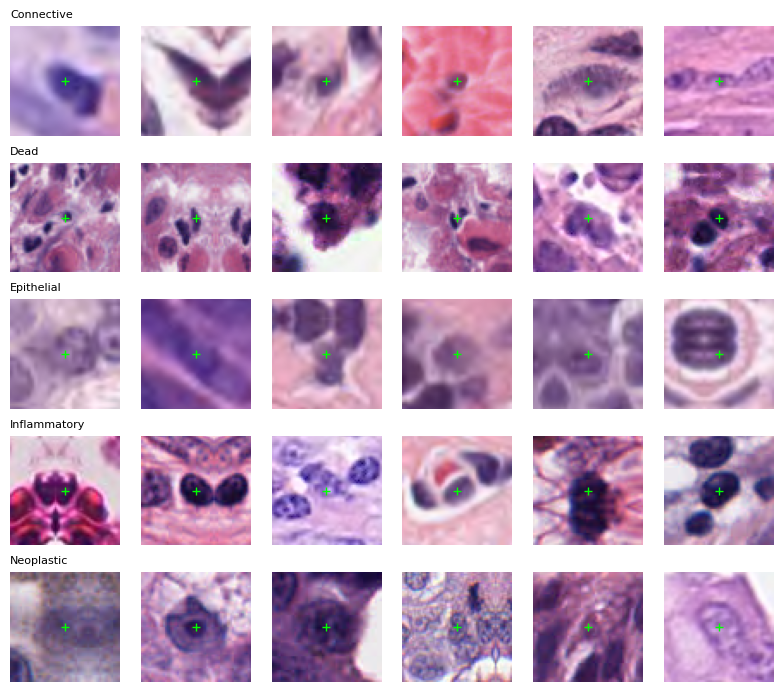

In [14]:
# A few crops per class (the nucleus should sit in the centre of every crop).
fig, axes = plt.subplots(len(CLASSES), 6, figsize=(8, 7))
ds = datasets["train"]
by_class = {i: [j for j, s in enumerate(ds.samples) if s[3] == i] for i in range(len(CLASSES))}
for i, cls in enumerate(CLASSES):
    picks = random.sample(by_class[i], min(6, len(by_class[i])))
    for j, ax in enumerate(axes[i]):
        ax.axis("off")
        if j < len(picks):
            ax.imshow(Image.open(ds.samples[picks[j]][2]).convert("RGB"))
            ax.plot(CROP_SIZE / 2 - 0.5, CROP_SIZE / 2 - 0.5, "+", color="lime", ms=6)
    axes[i, 0].set_title(cls, fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## 6. Feature extraction

In [15]:
_amp_dtype = getattr(torch, AMP_DTYPE)
def embed(model, imgs):
    out = model.forward_features(imgs)
    if FEATURE_MODE == "cls":
        return out["cls"]
    if FEATURE_MODE == "cls+patchmean":
        return torch.cat([out["cls"], out["patch"].mean(1)], dim=-1)
    raise ValueError(FEATURE_MODE)


@torch.no_grad()
def extract_features(model, dataset, desc):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=device.type == "cuda")
    feats, labels, ids = [], [], []
    for imgs, y, uid in tqdm(loader, desc=desc):
        imgs = imgs.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=_amp_dtype,
                            enabled=USE_AMP and device.type == "cuda"):
            f = embed(model, imgs)
        feats.append(f.float().cpu().numpy())
        labels.append(y.numpy())
        ids.extend(uid)
    return np.concatenate(feats), np.concatenate(labels), np.array(ids)


features = {}
for split, ds in datasets.items():
    cache = OUTPUT_DIR / f"{MODEL_TAG}_{FEATURE_MODE.replace('+', '_')}_{split}_features.npz"
    if CACHE_FEATURES and cache.exists():
        d = np.load(cache, allow_pickle=False)
        if len(d["labels"]) == len(ds):
            features[split] = (d["features"], d["labels"], d["ids"])
            print(f"Loaded cached {split} features {d['features'].shape} from {cache}")
            continue
        print(f"Cache {cache} has {len(d['labels'])} rows but dataset has {len(ds)} -- re-extracting")
    t0 = time.time()
    X, y, ids = extract_features(model, ds, f"Extracting {split}")
    np.savez_compressed(cache, features=X, labels=y, ids=ids)
    features[split] = (X, y, ids)
    print(f"{split}: {X.shape} in {time.time() - t0:.0f}s -> {cache}")

X_train, y_train, _ = features["train"]
X_val,   y_val,   _ = features["val"]
X_test,  y_test,  _ = features["test"]

Extracting train:   0%|          | 0/244 [00:00<?, ?it/s]

train: (62411, 384) in 161s -> /content/drive/MyDrive/C-LITE/vit5_small_p4_pannuke_results/vit5_small_p4_cls_train_features.npz


Extracting val:   0%|          | 0/231 [00:00<?, ?it/s]

val: (59083, 384) in 176s -> /content/drive/MyDrive/C-LITE/vit5_small_p4_pannuke_results/vit5_small_p4_cls_val_features.npz


Extracting test:   0%|          | 0/257 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b08c97d620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


test: (65764, 384) in 196s -> /content/drive/MyDrive/C-LITE/vit5_small_p4_pannuke_results/vit5_small_p4_cls_test_features.npz


## 7. Classifiers & metrics

In [16]:
def compute_metrics(y_true, y_pred, proba, n_classes=len(CLASSES)):
    m = {
        "Accuracy":        accuracy_score(y_true, y_pred),
        "Balanced_Acc":    balanced_accuracy_score(y_true, y_pred),
        "Macro_F1":        f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1":     f1_score(y_true, y_pred, average="weighted"),
        "Macro_Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro_Recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Cohen_Kappa":     cohen_kappa_score(y_true, y_pred),
    }
    if proba is not None:
        y_bin = label_binarize(y_true, classes=list(range(n_classes)))
        m["AUROC"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        m["mAP"]   = average_precision_score(y_bin, proba, average="macro")
        m["LogLoss"] = log_loss(y_true, proba, labels=list(range(n_classes)))
    for c, f in zip(CLASSES, f1_score(y_true, y_pred, average=None, labels=list(range(n_classes)))):
        m[f"F1_{c}"] = f
    return m


def report(name, y_true, y_pred, proba):
    m = compute_metrics(y_true, y_pred, proba)
    print(f"\n=== {name} ===")
    for k, v in m.items():
        print(f"  {k:18s} {v:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4, zero_division=0))
    return m

In [17]:
# Linear probe
M, C = X_train.shape[1], len(np.unique(y_train))
l2 = 100 / (M * C)
print(f"features={M}, classes={C}, l2={l2:.5f}, C={1 / l2:.2f}")

t0 = time.time()
logreg = LogisticRegression(C=1 / l2, max_iter=LOGREG_MAX_ITER, solver="lbfgs")
logreg.fit(X_train, y_train)
print(f"fit in {time.time() - t0:.0f}s")

results = {}
results["logreg_val"]  = report("LogReg | val (Fold2)",  y_val,  logreg.predict(X_val),  logreg.predict_proba(X_val))
results["logreg_test"] = report("LogReg | test (Fold3)", y_test, logreg.predict(X_test), logreg.predict_proba(X_test))

features=384, classes=5, l2=0.05208, C=19.20
fit in 77s

=== LogReg | val (Fold2) ===
  Accuracy           0.7564
  Balanced_Acc       0.7038
  Macro_F1           0.7091
  Weighted_F1        0.7546
  Macro_Precision    0.7166
  Macro_Recall       0.7038
  Cohen_Kappa        0.6609
  AUROC              0.9321
  mAP                0.7684
  LogLoss            0.6629
  F1_Connective      0.7245
  F1_Dead            0.5792
  F1_Epithelial      0.6855
  F1_Inflammatory    0.7377
  F1_Neoplastic      0.8184
              precision    recall  f1-score   support

  Connective     0.7374    0.7121    0.7245     16527
        Dead     0.5802    0.5782    0.5792       863
  Epithelial     0.7433    0.6360    0.6855      8762
Inflammatory     0.7317    0.7438    0.7377     10488
  Neoplastic     0.7902    0.8486    0.8184     22443

    accuracy                         0.7564     59083
   macro avg     0.7166    0.7038    0.7091     59083
weighted avg     0.7550    0.7564    0.7546     59083


=== 

## 8. Summary, confusion matrix, save

In [19]:
keys = list(results["logreg_test"].keys())
print(f"{'metric':18s}" + "".join(f"{r:>14s}" for r in results))
for k in keys:
    print(f"{k:18s}" + "".join(f"{results[r].get(k, float('nan')):14.4f}" for r in results))

out_csv = OUTPUT_DIR / f"{MODEL_TAG}_{FEATURE_MODE.replace('+', '_')}_pannuke_metrics.csv"
with open(out_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["run"] + keys)
    for r, m in results.items():
        w.writerow([r] + [m.get(k, "") for k in keys])
print("\nSaved", out_csv)

metric                logreg_val   logreg_test
Accuracy                  0.7564        0.7600
Balanced_Acc              0.7038        0.6902
Macro_F1                  0.7091        0.7030
Weighted_F1               0.7546        0.7576
Macro_Precision           0.7166        0.7190
Macro_Recall              0.7038        0.6902
Cohen_Kappa               0.6609        0.6556
AUROC                     0.9321        0.9333
mAP                       0.7684        0.7665
LogLoss                   0.6629        0.6466
F1_Connective             0.7245        0.7153
F1_Dead                   0.5792        0.5821
F1_Epithelial             0.6855        0.6599
F1_Inflammatory           0.7377        0.7254
F1_Neoplastic             0.8184        0.8325

Saved /content/drive/MyDrive/C-LITE/vit5_small_p4_pannuke_results/vit5_small_p4_cls_pannuke_metrics.csv


KeyboardInterrupt: 

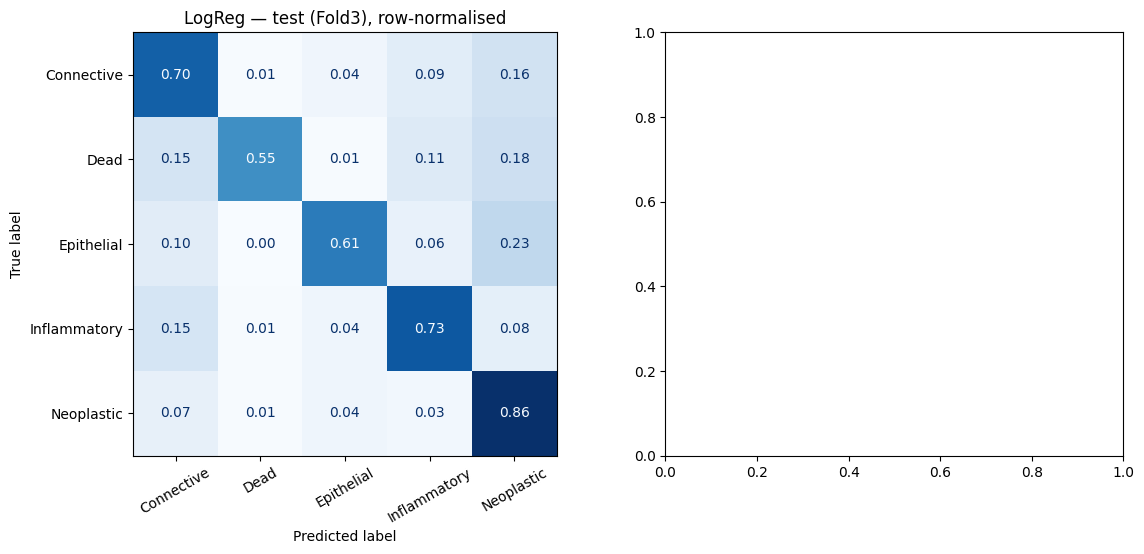

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, clf, Xt) in zip(axes, [("LogReg", logreg, X_test)]):
    cm = confusion_matrix(y_test, clf.predict(Xt), normalize="true", labels=list(range(len(CLASSES))))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(f"{name} — test (Fold3), row-normalised")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150)
plt.show()

## 9. Visualization



In [21]:
VIS_PATHS = None
# VIS_PATHS = [
#     "/tia/phd-data/u5552013/ImmunoDINO_datasets/PanNuke/Fold1_cell_patches/Connective/fold1_00002_00010_Connective_Breast.png",
#     "/tia/phd-data/u5552013/ImmunoDINO_datasets/PanNuke/Fold1_cell_patches/Epithelial/fold1_00045_00003_Epithelial_Breast.png",
# ]
ATTN_BLOCK_IDX = -1      # which transformer block to visualise (-1 = last, as in the script)
ATTN_MAX_HEADS = 8       # heads per saved grid (ViT-5 small has 6)
ATTN_ALPHA     = 0.5

VIS_DIR  = OUTPUT_DIR / "visualizations"
ATTN_DIR = VIS_DIR / "attention"
PCA_DIR  = VIS_DIR / "pca"
for d in (ATTN_DIR, PCA_DIR):
    d.mkdir(parents=True, exist_ok=True)

if VIS_PATHS is None:
    rng = random.Random(SEED)
    test_ds = datasets["test"]
    VIS_PATHS = [rng.choice([s[2] for s in test_ds.samples if s[1] == c])
                 for c in CLASSES if any(s[1] == c for s in test_ds.samples)]
VIS_PATHS = [Path(p) for p in VIS_PATHS]


def load_and_preprocess(path, img_size=IMG_SIZE):
    """Same as the attention script: square resize, /255, mean/std normalise."""
    img = Image.open(path).convert("RGB").resize((img_size, img_size))
    arr = (np.asarray(img).astype(np.float32) / 255.0 - np.array(NORM_MEAN)) / np.array(NORM_STD)
    return torch.from_numpy(arr).permute(2, 0, 1).float()


def unnormalize_image(t):
    """(3,H,W) normalised tensor -> (H,W,3) uint8, like _unnormalize_image."""
    mean = torch.tensor(NORM_MEAN, dtype=t.dtype, device=t.device).view(3, 1, 1)
    std = torch.tensor(NORM_STD, dtype=t.dtype, device=t.device).view(3, 1, 1)
    return ((t * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)


def short_label(p):
    n = Path(p).stem
    return n.split("_")[3] if n.count("_") >= 3 else n


vis_imgs = torch.stack([load_and_preprocess(p) for p in VIS_PATHS])     # (B,3,64,64)
vis_u8 = [unnormalize_image(t) for t in vis_imgs]
print("\n".join(str(p) for p in VIS_PATHS))

/content/pannuke_hf_cell_crops/Fold3_cell_patches/Connective/fold3_00764_00021_Connective_Colon.png
/content/pannuke_hf_cell_crops/Fold3_cell_patches/Dead/fold3_00930_00091_Dead_Lung.png
/content/pannuke_hf_cell_crops/Fold3_cell_patches/Epithelial/fold3_01021_00027_Epithelial_Skin.png
/content/pannuke_hf_cell_crops/Fold3_cell_patches/Inflammatory/fold3_01008_00002_Inflammatory_Thyroid.png
/content/pannuke_hf_cell_crops/Fold3_cell_patches/Neoplastic/fold3_00879_00010_Neoplastic_Prostate.png


## 10. PCA Visualization



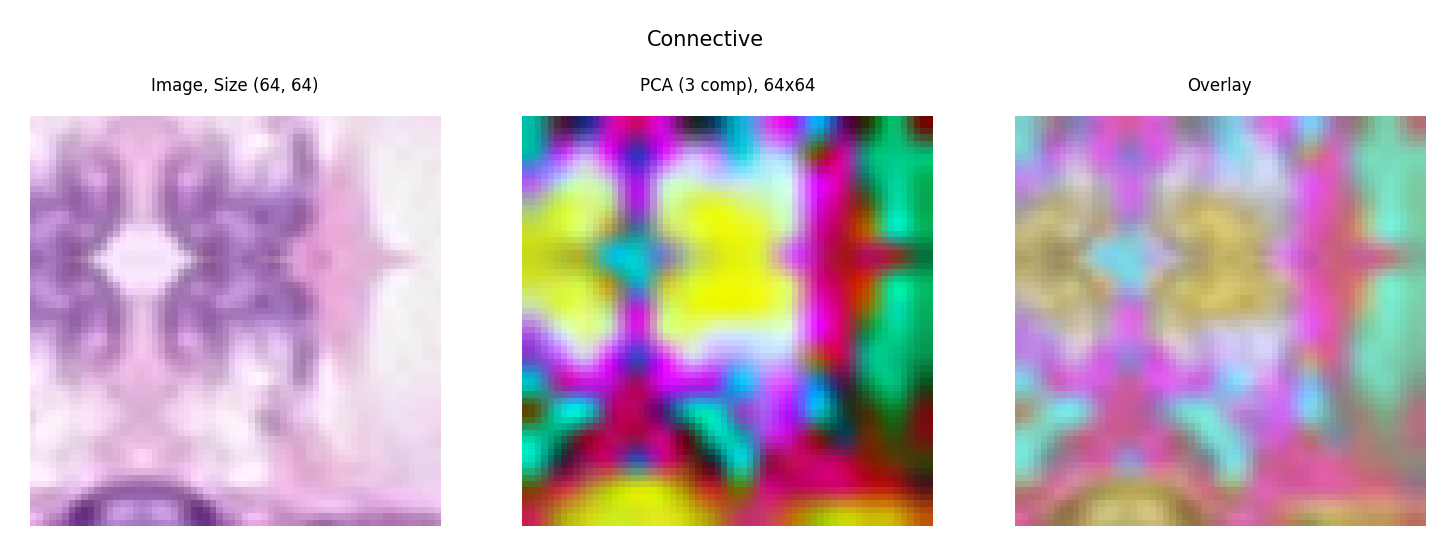

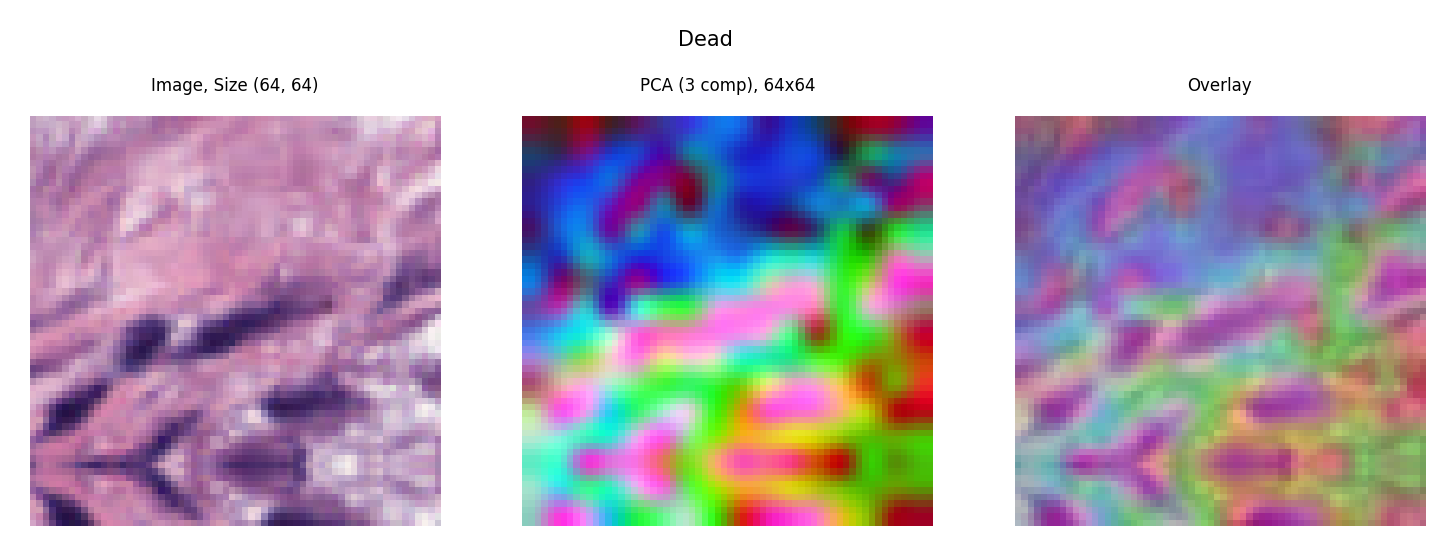

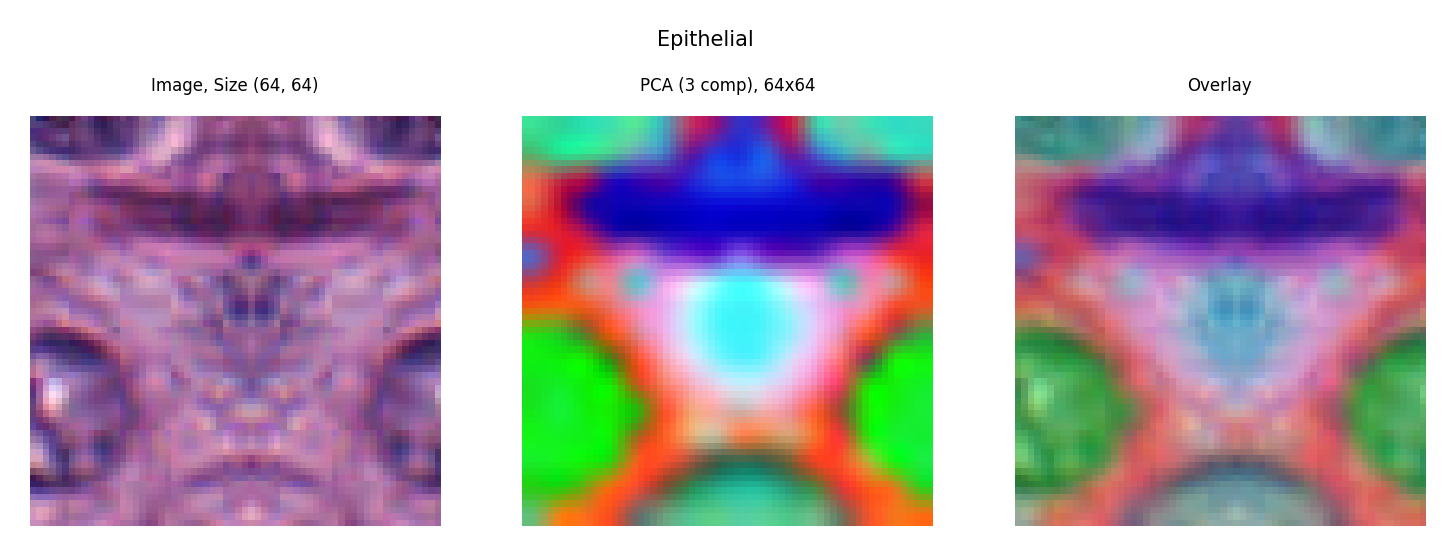

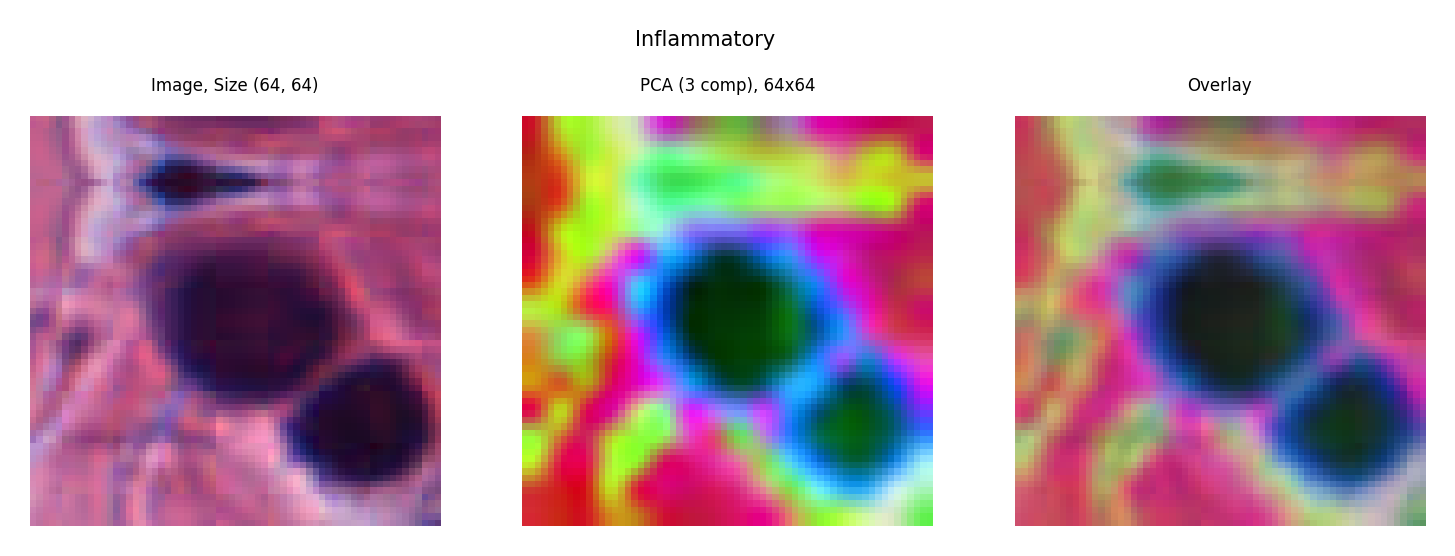

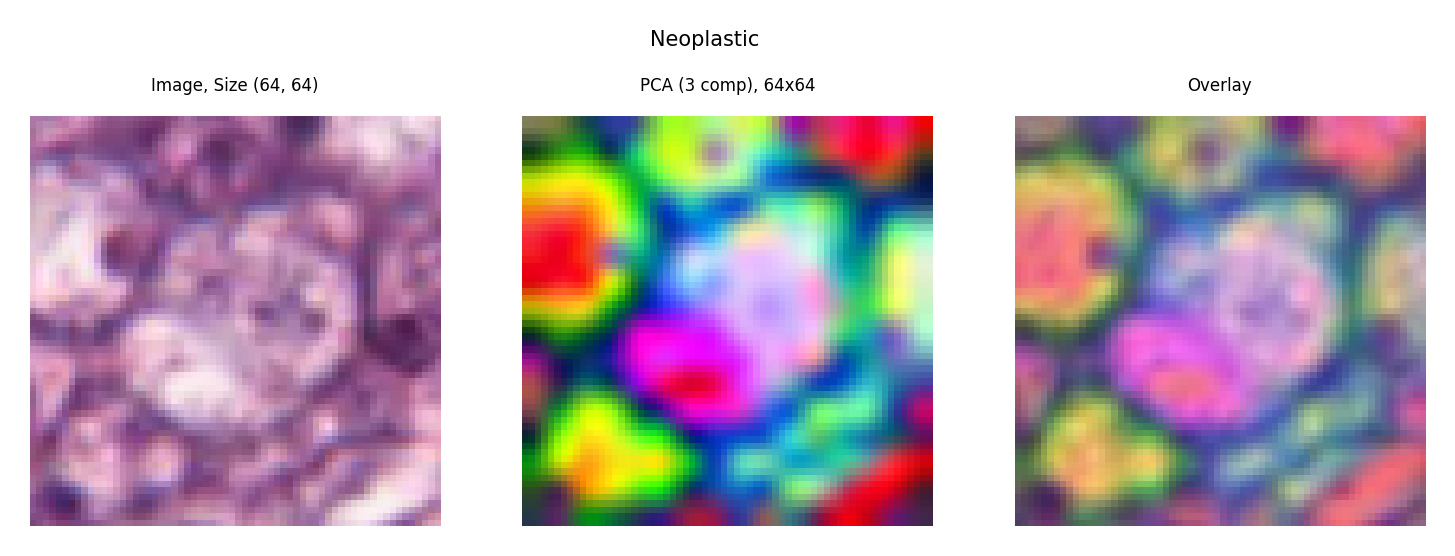

saved 5 PCA figures to /content/drive/MyDrive/C-LITE/vit5_small_p4_pannuke_results/visualizations/pca


In [24]:
import torchvision.transforms.functional as TF


def resize_transform(img, image_size=IMG_SIZE, patch_size=None):
    """Same as the script's resize_transform, returns an un-normalised (3,H,W) tensor in [0,1]."""
    patch_size = patch_size or model.patch_size
    w, h = img.size
    h_p = int(image_size / patch_size)
    w_p = int((w * image_size) / (h * patch_size))
    if w_p != h_p:
        print(f"  note: {w}x{h} image gives a {h_p}x{w_p} grid; ViT-5 RoPE needs a square grid -> resizing square")
        w_p = h_p
    return TF.to_tensor(TF.resize(img, (h_p * patch_size, w_p * patch_size)))


@torch.no_grad()
def patch_tokens(model, img_norm):
    """(1,3,H,W) -> (h_p*w_p, C) final-norm patch tokens."""
    return model.forward_features(img_norm.unsqueeze(0).to(device))["patch"][0].float().cpu()


def pca_rgb(proj, h_p, w_p, out_hw):
    t = torch.sigmoid(torch.as_tensor(proj, dtype=torch.float32).mul(2.0)).view(h_p, w_p, 3).permute(2, 0, 1)
    t = F.interpolate(t.unsqueeze(0), size=out_hw, mode="bicubic", align_corners=False).squeeze(0)
    return t.clamp(0, 1).permute(1, 2, 0).numpy()


pca_items = []   # (path, resized image, tokens, h_p, w_p) -- reused by the joint PCA below
for p in VIS_PATHS:
    image = Image.open(p).convert("RGB")
    img_r = resize_transform(image)
    x = patch_tokens(model, TF.normalize(img_r, mean=NORM_MEAN, std=NORM_STD))
    h_p, w_p = [d // model.patch_size for d in img_r.shape[1:]]
    pca_items.append((p, img_r, x, h_p, w_p))

    proj = PCA(n_components=3, whiten=True).fit(x.numpy()).transform(x.numpy())
    img_h, img_w = img_r.shape[1:]
    pca_up = pca_rgb(proj, h_p, w_p, (img_h, img_w))
    img_np = img_r.permute(1, 2, 0).numpy()

    with plt.rc_context({"axes.titlesize": 4}):
        fig = plt.figure(figsize=(6, 2), dpi=300)
        for k, (pnl, title) in enumerate([(image, f"Image, Size {image.size}"),
                                          (pca_up, f"PCA (3 comp), {img_h}x{img_w}"),
                                          (0.5 * img_np + 0.5 * pca_up, "Overlay")]):
            ax = fig.add_subplot(1, 3, k + 1)
            ax.imshow(pnl); ax.set_title(title); ax.axis("off")
        fig.suptitle(short_label(p), fontsize=5)
        fig.savefig(PCA_DIR / f"pca_{p.stem}.png", bbox_inches="tight")
        plt.show()
print(f"saved {len(VIS_PATHS)} PCA figures to {PCA_DIR}")

explained variance ratio: [0.118 0.062 0.057]


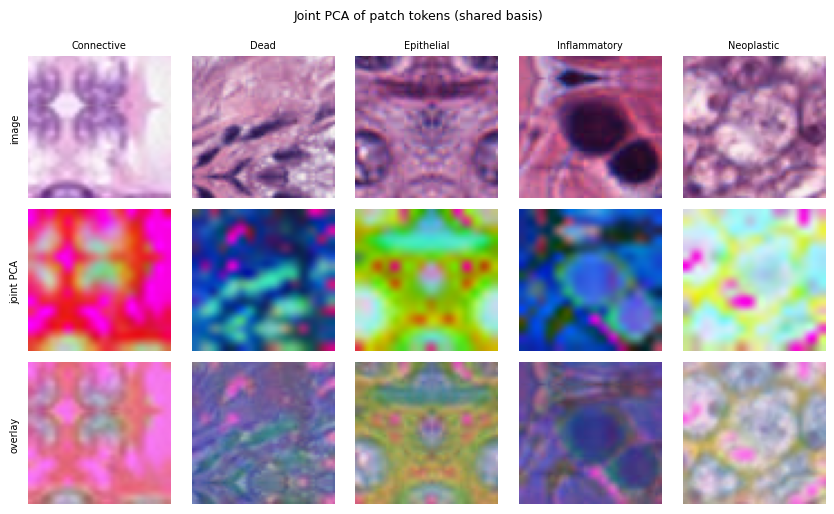

In [25]:
# Joint PCA: one basis fitted on the patches of all images, so a colour means the same thing in every crop.

all_tok = torch.cat([it[2] for it in pca_items]).numpy()
joint = PCA(n_components=3, whiten=True).fit(all_tok)
print("explained variance ratio:", np.round(joint.explained_variance_ratio_, 3))

n = len(pca_items)
fig, axes = plt.subplots(3, n, figsize=(1.7 * n, 5.2), squeeze=False)
for i, (p, img_r, x, h_p, w_p) in enumerate(pca_items):
    img_np = img_r.permute(1, 2, 0).numpy()
    rgb = pca_rgb(joint.transform(x.numpy()), h_p, w_p, tuple(img_r.shape[1:]))
    for r, pnl in enumerate([img_np, rgb, 0.5 * img_np + 0.5 * rgb]):
        axes[r, i].imshow(pnl); axes[r, i].axis("off")
    axes[0, i].set_title(short_label(p), fontsize=7)
for r, t in enumerate(["image", "joint PCA", "overlay"]):
    axes[r, 0].text(-4, img_r.shape[1] / 2, t, rotation=90, va="center", ha="right", fontsize=7)
plt.suptitle("Joint PCA of patch tokens (shared basis)", fontsize=9)
plt.tight_layout()
plt.savefig(PCA_DIR / "pca_joint.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. TSNE / UMAP Visualization

test: using 20000 / 65764 cells -> {'Connective': 5041, 'Dead': 1036, 'Epithelial': 2556, 'Inflammatory': 3129, 'Neoplastic': 8238}
t-SNE done in 244s


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done in 44s


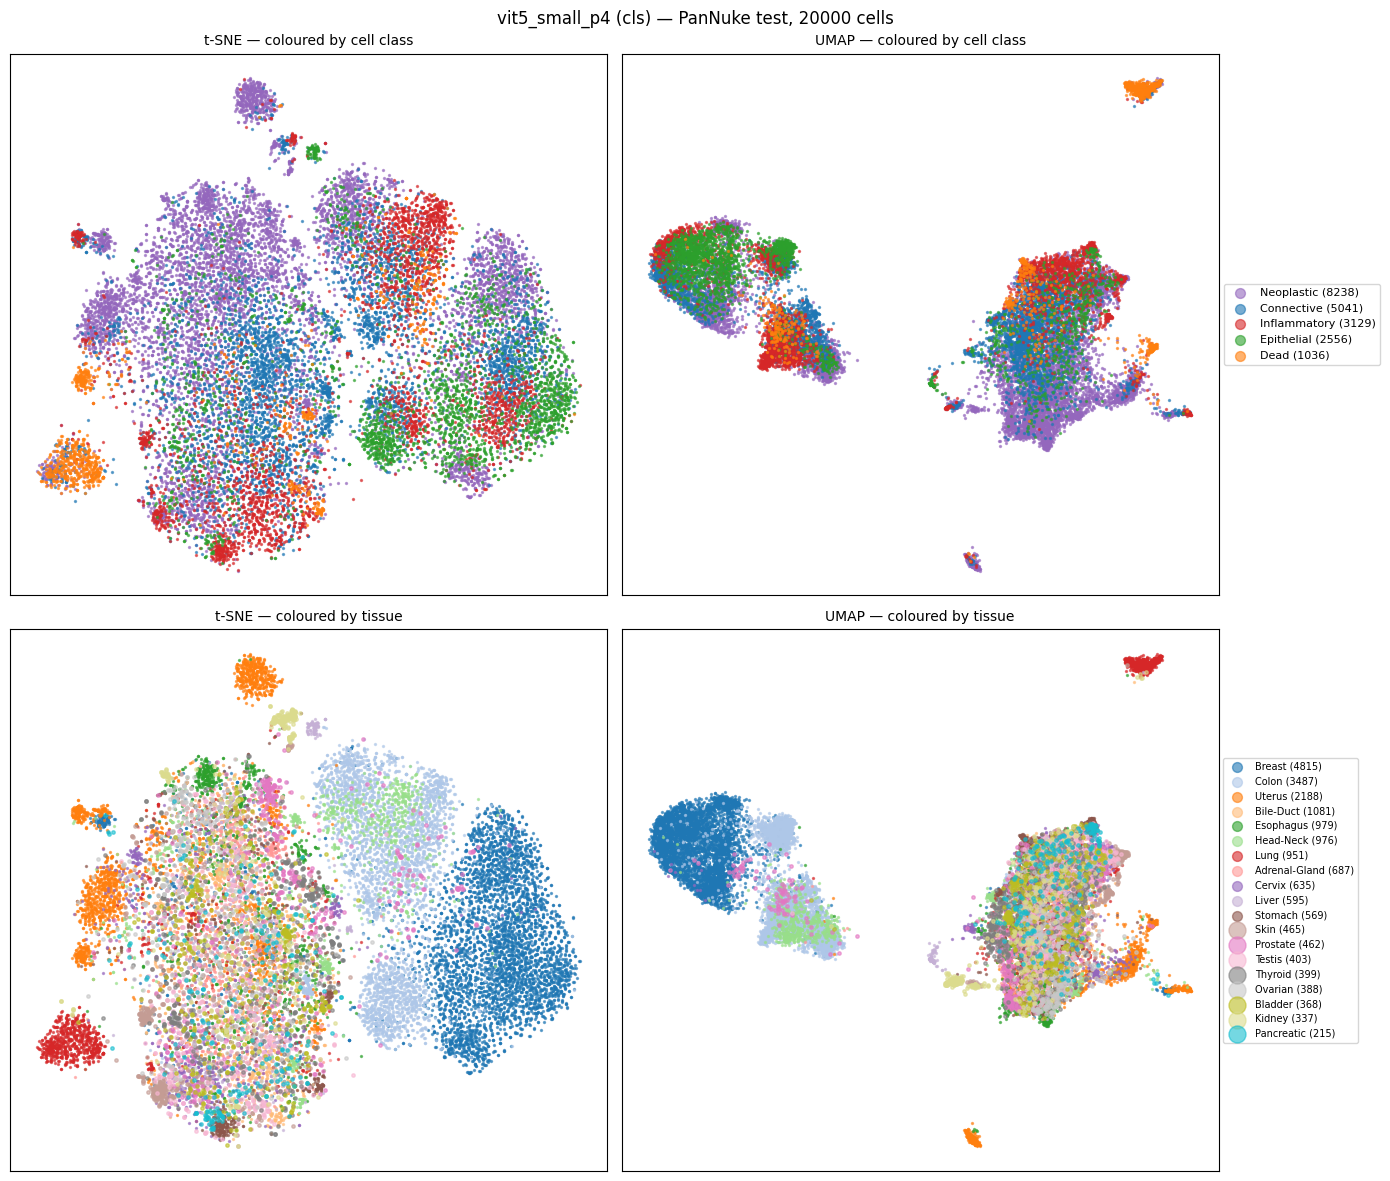

saved /content/drive/MyDrive/C-LITE/vit5_small_p4_pannuke_results/visualizations/embeddings/tsne_umap_test.png


In [26]:
# ---- t-SNE / UMAP of the extracted features --------------------------------------------
# Uses `features`, `CLASSES`, `OUTPUT_DIR`, `MODEL_TAG`, `FEATURE_MODE`, `SEED` from the notebook.
try:
    import umap
except ImportError:                      # Colab / fresh env
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"], check=True)
    import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

EMB_SPLIT       = "test"        # "train", "val" or "test"
EMB_MAX_POINTS  = 20000         # t-SNE is slow on 60k+ points; rare classes are always kept in full
EMB_KEEP_ALL    = ["Dead"]      # classes never subsampled
EMB_PCA_DIMS    = 50            # PCA before t-SNE/UMAP: faster and less noisy
TSNE_PERPLEXITY = 30
UMAP_NEIGHBORS  = 30
UMAP_MIN_DIST   = 0.1

X_all, y_all, ids_all = features[EMB_SPLIT]

# stratified subsample: every class shrinks by the same factor, EMB_KEEP_ALL classes are kept whole
rng = np.random.default_rng(SEED)
keep_ids = [CLASSES.index(c) for c in EMB_KEEP_ALL if c in CLASSES]
always = np.flatnonzero(np.isin(y_all, keep_ids))
rest = np.flatnonzero(~np.isin(y_all, keep_ids))
budget = max(EMB_MAX_POINTS - len(always), 0)
if len(rest) > budget:
    frac = budget / len(rest)
    rest = np.concatenate([rng.choice(idx, max(1, int(round(len(idx) * frac))), replace=False)
                           for c in np.unique(y_all[rest]) for idx in [rest[y_all[rest] == c]]])
sel = np.sort(np.concatenate([always, rest]))
X, y, ids = X_all[sel], y_all[sel], ids_all[sel]
tissue = np.array([s.split("_")[4] if s.count("_") >= 4 else "?" for s in ids])
print(f"{EMB_SPLIT}: using {len(sel)} / {len(y_all)} cells ->",
      {c: int((y == i).sum()) for i, c in enumerate(CLASSES)})

# L2-normalise (same as the kNN probe), then PCA
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
Xp = PCA(n_components=min(EMB_PCA_DIMS, Xn.shape[1], len(Xn) - 1), random_state=SEED).fit_transform(Xn)

t0 = time.time()
emb = {"t-SNE": TSNE(n_components=2, perplexity=min(TSNE_PERPLEXITY, (len(Xp) - 1) / 3),
                     init="pca", learning_rate="auto", random_state=SEED).fit_transform(Xp)}
print(f"t-SNE done in {time.time() - t0:.0f}s"); t0 = time.time()
emb["UMAP"] = umap.UMAP(n_neighbors=min(UMAP_NEIGHBORS, len(Xp) - 1), min_dist=UMAP_MIN_DIST,
                        metric="euclidean", random_state=SEED).fit_transform(Xp)
print(f"UMAP done in {time.time() - t0:.0f}s")


def scatter(ax, Z, labels, names, title, cmap="tab10"):
    colors = plt.get_cmap(cmap if len(names) <= 10 else "tab20")
    order = np.argsort([-(labels == n).sum() for n in names])          # draw big classes first
    for k in order:
        m = labels == names[k]
        ax.scatter(Z[m, 0], Z[m, 1], s=2 if m.sum() > 500 else 6, alpha=0.6,
                   color=colors(k % colors.N), label=f"{names[k]} ({m.sum()})", rasterized=True)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])


class_names = np.array(CLASSES)[y]
tissues = sorted(set(tissue), key=lambda t: -(tissue == t).sum())
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for col, (name, Z) in enumerate(emb.items()):
    scatter(axes[0, col], Z, class_names, CLASSES, f"{name} — coloured by cell class")
    scatter(axes[1, col], Z, tissue, tissues, f"{name} — coloured by tissue")
axes[0, 1].legend(markerscale=5, fontsize=8, loc="center left", bbox_to_anchor=(1, 0.5))
axes[1, 1].legend(markerscale=5, fontsize=7, loc="center left", bbox_to_anchor=(1, 0.5), ncol=1)
fig.suptitle(f"{MODEL_TAG} ({FEATURE_MODE}) — PanNuke {EMB_SPLIT}, {len(sel)} cells", fontsize=12)
plt.tight_layout()
emb_dir = OUTPUT_DIR / "visualizations" / "embeddings"
emb_dir.mkdir(parents=True, exist_ok=True)
out = emb_dir / f"tsne_umap_{EMB_SPLIT}.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
np.savez_compressed(emb_dir / f"tsne_umap_{EMB_SPLIT}.npz", tsne=emb["t-SNE"], umap=emb["UMAP"],
                    labels=y, ids=ids)
print("saved", out)